# **Algoritmos para Bioinformática/Bioinformática 2024/2025**

By: David Pinto (up201704300@up.pt)  
Diogo Monteiro (up202108800@up.pt)  
Eduardo Oliveira (up202108690@up.pt)  

## **Assignment 2: Cancer Subtype Classification**

This project investigates the application of machine learning techniques to classify molecular subtypes of Glioblastoma Multiforme (GBM), a highly aggressive brain cancer. Specifically, the study focuses on distinguishing between the Classical (prognostically favorable) and Mesenchymal (prognostically adverse) subtypes using high-dimensional gene expression data. Through both unsupervised and supervised learning approaches, the goal is to assess whether gene expression patterns can reveal intrinsic biological structure and enable accurate subtype prediction. The insights gained from this classification task can support improved prognosis and the development of personalized treatment strategies.

### **0. Necessary Imports and Utils**

In this section we make the necessary imports and define some utility functions for our experiments.

In [115]:
!pip install -r requirements.txt

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import umap.umap_ as umap

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

from sklearn.model_selection import StratifiedKFold,train_test_split, cross_val_score,cross_validate
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

def split_data(df, str_target):
    """Splits a dataframe into features (X) and target (y)"""
    X = df.drop(str_target, axis=1)
    y = df[str_target]
    return X, y

def eval(X,y,min=3,max=50,reduction='PCA',clustering='kmeans'):
    scaler = StandardScaler()
    if(clustering == 'kmeans'):
        kmeans = KMeans(n_clusters=2, random_state=42,init='k-means++',n_init=40,max_iter=300)
        if(reduction == 'PCA'):
            best_result = min
            best_V_measur = -1
            best_Completeness = -1
            best_Homogeneity = -1
            for i in range(min,max):
                pca = PCA(n_components=i, random_state=42)
                
                X_scaled = scaler.fit_transform(X)
                X_pca = pca.fit_transform(X_scaled)
                clusters_pca_kmean = kmeans.fit_predict(X_pca)
                
                if(best_Completeness < completeness_score(y, clusters_pca_kmean)):
                    best_Homogeneity = homogeneity_score(y, clusters_pca_kmean)
                    best_Completeness = completeness_score(y, clusters_pca_kmean)
                    best_V_measur = v_measure_score(y, clusters_pca_kmean)
                    best_result = i

            pca = PCA(n_components=best_result, random_state=42)       
            X_scaled = scaler.fit_transform(X)
            X_new = pca.fit_transform(X_scaled)
            cluster = kmeans.fit_predict(X_new)
        elif(reduction == 'UMAP'):
            best_result = min
            best_V_measur = -1
            best_Completeness = -1
            best_Homogeneity = -1
            for i in range(min,max):
                reducer = umap.UMAP(n_components=i, random_state=42)
                
                X_scaled = scaler.fit_transform(X)
                X_umap = reducer.fit_transform(X_scaled)
                clusters_umap_kmean = kmeans.fit_predict(X_umap)
                
                if(best_Completeness < completeness_score(y, clusters_umap_kmean)):
                    best_Homogeneity = homogeneity_score(y, clusters_umap_kmean)
                    best_Completeness = completeness_score(y, clusters_umap_kmean)
                    best_V_measur = v_measure_score(y, clusters_umap_kmean)
                    best_result = i

            reducer = umap.UMAP(n_components=best_result, random_state=42)   
            X_scaled = scaler.fit_transform(X)
            X_new = reducer.fit_transform(X_scaled)
            cluster = kmeans.fit_predict(X_new)
        else:
            return 'Error - reduction technique does not supported'
    elif(clustering == 'hierarchical'):
        hierarchical = AgglomerativeClustering(n_clusters=2)
        if(reduction == 'PCA'):
            best_result = min
            best_V_measur = -1
            best_Completeness = -1
            best_Homogeneity = -1
            for i in range(min,max):
                pca = PCA(n_components=i, random_state=42)
                
                X_scaled = scaler.fit_transform(X)
                X_pca = pca.fit_transform(X_scaled)
                clusters_pca_kmean = hierarchical.fit_predict(X_pca)
                
                if(best_Completeness < completeness_score(y, clusters_pca_kmean)):
                    best_Homogeneity = homogeneity_score(y, clusters_pca_kmean)
                    best_Completeness = completeness_score(y, clusters_pca_kmean)
                    best_V_measur = v_measure_score(y, clusters_pca_kmean)
                    best_result = i

            pca = PCA(n_components=best_result, random_state=42)       
            X_scaled = scaler.fit_transform(X)
            X_new = pca.fit_transform(X_scaled)
            cluster = hierarchical.fit_predict(X_new)
        elif(reduction == 'UMAP'):
            best_result = min
            best_V_measur = -1
            best_Completeness = -1
            best_Homogeneity = -1
            for i in range(min,max):
                reducer = umap.UMAP(n_components=i, random_state=42)
                
                X_scaled = scaler.fit_transform(X)
                X_umap = reducer.fit_transform(X_scaled)
                clusters_umap_kmean = hierarchical.fit_predict(X_umap)
                
                if(best_Completeness < completeness_score(y, clusters_umap_kmean)):
                    best_Homogeneity = homogeneity_score(y, clusters_umap_kmean)
                    best_Completeness = completeness_score(y, clusters_umap_kmean)
                    best_V_measur = v_measure_score(y, clusters_umap_kmean)
                    best_result = i

            reducer = umap.UMAP(n_components=best_result, random_state=42)   
            X_scaled = scaler.fit_transform(X)
            X_new = reducer.fit_transform(X_scaled)
            cluster = hierarchical.fit_predict(X_new)
        else:
            return 'Error - reduction technique does not supported'
    else:
        return 'Error - clustering method does not supported'

    print(f"choosed {clustering} with the reduction technique {reduction} and n_components = {best_result}")
    print(f"Homogeneity: {best_Homogeneity:.3f}")  # all clusters contain only members of a single class.
    print(f"Completeness: {best_Completeness:.3f}") # all members of a given class are assigned to the same cluster.
    print(f"V-measure: {best_V_measur:.3f}") # harmonic mean of homogeneity and completeness.
    

### Data Profiling & Preprocessing

In [116]:
df1 = pd.read_csv('./data/X_gexp.csv')
df2 = pd.read_csv('./data/y_gexp.csv')
df = pd.merge(df1, df2, on="Unnamed: 0")
df.head()

,Unnamed: 0,FSTL1,ELMO2,CREB3L1,PNMA1,MMP2,SMARCD3,PKNOX2,RALYL,ZHX3,...,PSMB9,ProSAPiP1,HCLS1,MMP9,KIAA0802,DHRS2,SGEF,PIK3IP1,CTSC,x
0,TCGA-02-0001-01,2.275179,1.873549,1.772059,2.144198,2.269443,1.742389,1.797055,1.677848,1.801352,...,2.346811,2.004333,2.213310,2.407606,2.083333,2.098461,1.680092,1.953595,2.429578,0
1,TCGA-02-0004-01,2.569520,2.085888,1.961846,2.315705,2.505400,2.226593,1.798769,1.671170,2.000942,...,2.339930,2.045828,2.285701,2.633632,1.938474,1.614437,1.760419,2.010156,2.431814,1
2,TCGA-02-0009-01,2.471492,2.030865,1.845808,2.072279,2.346815,1.783762,1.707150,1.599492,1.823480,...,2.302006,2.059862,2.130193,2.349831,1.815239,1.857933,1.675823,2.011970,2.434026,0
3,TCGA-02-0015-01,2.464403,2.094165,1.762169,2.374129,2.213562,2.209426,1.925440,1.936043,2.003743,...,2.208924,2.050555,2.213955,1.982603,2.125508,1.631955,1.881003,1.886280,2.450704,0
4,TCGA-02-0016-01,2.365457,2.188070,1.763206,2.340024,2.219210,2.308335,1.801007,1.756726,2.115714,...,2.187420,2.265522,2.192262,1.796491,1.979615,1.637215,2.182186,1.897957,2.140727,0


In [117]:
print(f"Number of Features : {df.shape[1]}")
print(f"Number of Rows : {df.shape[0]}")
print(f"Number of NaN : {df.isnull().sum().sum()}")
print(f"number of duplicates : {df.duplicated().sum()}")

Number of Features : 5002
Number of Rows : 302
Number of NaN : 0
number of duplicates : 0


### Unsupervised Leaning

In this section, we will test whether unsupervised learning can successfully separate the cancer subtypes using the current dataset and features. To do this, we will apply two dimensionality reduction techniques (PCA and UMAP), combined with two clustering algorithms (KMeans and hierarchical clustering).

We will also use three metrics to evaluate how well the unsupervised learning performs:

- Homogeneity: Measures whether each cluster contains only members of a single class. A high score means that the clusters are “pure” in terms of class labels.

- Completeness: Measures whether all members of a given class are assigned to the same cluster. A high score means that samples of the same class are not split across different clusters.

- V-measure: This is the harmonic mean of homogeneity and completeness, providing a balanced evaluation of the clustering quality.

In [118]:
X,y = split_data(df,'x')
X = X.drop('Unnamed: 0', axis=1)

In [119]:
eval(X,y,min=2,max=3,reduction='PCA',clustering='kmeans')

choosed kmeans with the reduction technique PCA and n_components = 2
Homogeneity: 0.014
Completeness: 0.015
V-measure: 0.015


In [120]:
eval(X,y,min=2,max=3,reduction='UMAP',clustering='kmeans')

choosed kmeans with the reduction technique UMAP and n_components = 2
Homogeneity: 0.009
Completeness: 0.010
V-measure: 0.010


In [121]:
eval(X,y,min=2,max=3,reduction='PCA',clustering='hierarchical')

choosed hierarchical with the reduction technique PCA and n_components = 2
Homogeneity: 0.004
Completeness: 0.004
V-measure: 0.004


In [122]:
eval(X,y,min=2,max=3,reduction='UMAP',clustering='hierarchical')

choosed hierarchical with the reduction technique UMAP and n_components = 2
Homogeneity: 0.003
Completeness: 0.004
V-measure: 0.004


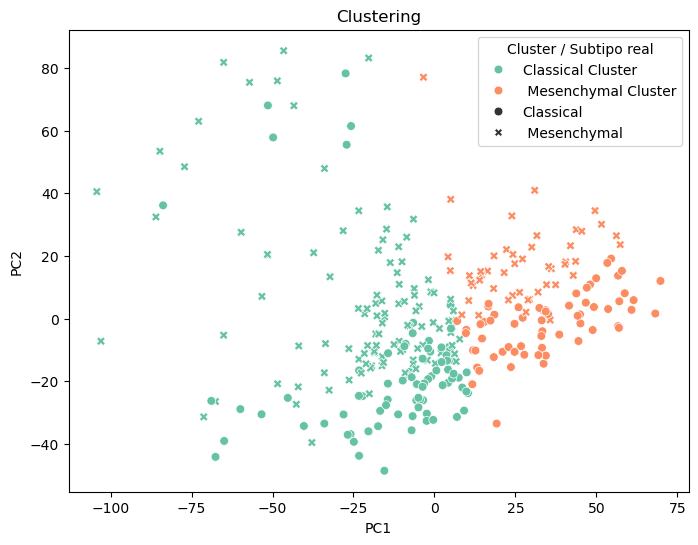

choosed kmeans with the reduction technique PCA and n_components = 2
Homogeneity: 0.014
Completeness: 0.015
V-measure: 0.015


In [123]:
scaler = StandardScaler()
kmeans = KMeans(n_clusters=2, random_state=42,init='k-means++',n_init=40,max_iter=300)
pca = PCA(n_components=2, random_state=42)

X_scaled = scaler.fit_transform(X)
X_pca = pca.fit_transform(X_scaled)
clusters_pca_kmean = kmeans.fit_predict(X_pca)

subtype_labels = np.where(y == 0, 'Classical', ' Mesenchymal')
cluster_labels = np.where(clusters_pca_kmean == 0, 'Classical Cluster ', ' Mesenchymal Cluster')
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=cluster_labels, palette='Set2', style=subtype_labels,s=40)
plt.title("Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster / Subtipo real")
plt.show()
eval(X,y,min=2,max=3,reduction='PCA',clustering='kmeans')

Are the subtypes of cancer (Classical and Mesenchymal) recapitulated using these methods?

We tested the use of PCA and UMAP as dimensionality reduction techniques, combined with both KMeans and hierarchical clustering algorithms. For visualization purposes, we used n_components = 2, allowing us to project the data into 2D space.

The best result was achieved using PCA followed by KMeans clustering, which yielded the following evaluation scores:
Homogeneity: 0.014
Completeness: 0.015
V-measure: 0.015

These very low values indicate that the clustering does not meaningfully capture or separate the known cancer subtypes (Classical and Mesenchymal). In other words, the clusters formed do not align with the true subtype labels, suggesting that these subtypes are not well recapitulated using the unsupervised methods applied here.

### Supervised Learning

In [124]:
scoring = ['accuracy', 'precision', 'recall', 'f1']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [125]:
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif, k=100)),  # seleciona as top 100 features
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [126]:
scores_rf = cross_validate(pipeline_rf, X, y, cv=cv, scoring=scoring)


In [127]:
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif, k=100)),
    ('clf', SVC(kernel='rbf', C=1, gamma='scale', random_state=42))
])

In [128]:
scores_svm = cross_validate(pipeline_svm, X, y, cv=cv, scoring=scoring)

In [129]:
pipeline_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif, k=100)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

In [130]:
scores_logreg = cross_validate(pipeline_logreg, X, y, cv=cv, scoring=scoring)

In [131]:
pipeline_nb = Pipeline([
    ('scaler', StandardScaler()),  # Opcional para GaussianNB, mas pode ajudar
    ('selector', SelectKBest(score_func=f_classif, k=100)),
    ('clf', GaussianNB())
])

In [132]:
scores_nb = cross_validate(pipeline_nb, X, y, cv=cv, scoring=scoring)

In [133]:
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif, k=100)),
    ('clf', KNeighborsClassifier(n_neighbors=5))
])

In [134]:
scores_knn = cross_validate(pipeline_knn, X, y, cv=cv, scoring=scoring)

In [135]:
def print_scores(name, scores):
    print(f"\n{name} Results:")
    for metric in scoring:
        mean = scores[f'test_{metric}'].mean()
        std = scores[f'test_{metric}'].std()
        print(f"{metric.capitalize()}: {mean:.3f} ± {std:.3f}")

print_scores("Random Forest", scores_rf)
print_scores("SVM", scores_svm)
print_scores("Logistic Regression", scores_logreg)
print_scores("Naive Bayes", scores_nb)
print_scores("K-Nearest Neighbors", scores_knn)


Random Forest Results:
Accuracy: 0.904 ± 0.019
Precision: 0.892 ± 0.032
Recall: 0.930 ± 0.037
F1: 0.910 ± 0.017

SVM Results:
Accuracy: 0.934 ± 0.031
Precision: 0.921 ± 0.022
Recall: 0.955 ± 0.056
F1: 0.937 ± 0.032

Logistic Regression Results:
Accuracy: 0.894 ± 0.034
Precision: 0.909 ± 0.031
Recall: 0.885 ± 0.044
F1: 0.896 ± 0.034

Naive Bayes Results:
Accuracy: 0.891 ± 0.027
Precision: 0.889 ± 0.029
Recall: 0.904 ± 0.067
F1: 0.895 ± 0.030

K-Nearest Neighbors Results:
Accuracy: 0.907 ± 0.031
Precision: 0.911 ± 0.021
Recall: 0.910 ± 0.055
F1: 0.910 ± 0.031
